In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd


PROJECT_ROOT = (
    Path("..")
    if Path.cwd().name == "notebooks"
    else Path(".")
)

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "portfolio_returns.csv"
)

EXPECTED_COLUMNS = [
    "date",
    "HPG_simple_return",
    "FPT_simple_return",
    "MWG_simple_return",
    "portfolio_simple_return",
    "portfolio_log_return",
]


if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Canonical portfolio dataset not found: {DATA_PATH.resolve()}"
    )


portfolio_data = pd.read_csv(DATA_PATH)

if portfolio_data.columns.tolist() != EXPECTED_COLUMNS:
    raise ValueError(
        "Unexpected portfolio dataset schema.\n"
        f"Expected: {EXPECTED_COLUMNS}\n"
        f"Received: {portfolio_data.columns.tolist()}"
    )


portfolio_data["date"] = pd.to_datetime(
    portfolio_data["date"],
    errors="raise",
)

portfolio_data = (
    portfolio_data
    .sort_values("date")
    .reset_index(drop=True)
)


duplicate_dates = int(
    portfolio_data["date"].duplicated().sum()
)

missing_values = (
    portfolio_data[EXPECTED_COLUMNS]
    .isna()
    .sum()
)

portfolio_returns = pd.to_numeric(
    portfolio_data["portfolio_simple_return"],
    errors="raise",
).astype("float64")

finite_returns = np.isfinite(
    portfolio_returns.to_numpy()
)

nonfinite_count = int(
    (~finite_returns).sum()
)


if portfolio_data.empty:
    raise ValueError(
        "Canonical portfolio dataset is empty."
    )

if duplicate_dates != 0:
    raise ValueError(
        f"Duplicate portfolio dates detected: {duplicate_dates}"
    )

if missing_values.sum() != 0:
    raise ValueError(
        "Missing values detected in canonical portfolio dataset:\n"
        f"{missing_values[missing_values > 0]}"
    )

if nonfinite_count != 0:
    raise ValueError(
        "Portfolio simple returns contain "
        f"{nonfinite_count} non-finite values."
    )


print("HISTORICAL VAR INPUT AUDIT")
print(f"Data path: {DATA_PATH.resolve()}")
print(f"Rows: {len(portfolio_data)}")
print(
    "Date range:",
    portfolio_data["date"].min().date(),
    "->",
    portfolio_data["date"].max().date(),
)
print(f"Duplicate dates: {duplicate_dates}")
print(f"Missing values: {int(missing_values.sum())}")
print(f"Non-finite portfolio returns: {nonfinite_count}")
print(
    "Portfolio return range:",
    f"{portfolio_returns.min():.6%}",
    "->",
    f"{portfolio_returns.max():.6%}",
)

print("\nCanonical VaR series:")
print(portfolio_returns.head())


--- HISTORICAL VAR INPUT AUDIT ---
Data path: C:\Users\Admin\Downloads\portfolio-var-risk-system\data\processed\portfolio_returns.csv
Rows: 1637
Date range: 2020-01-03 -> 2026-07-28
Duplicate dates: 0
Missing values: 0
Non-finite portfolio returns: 0
Portfolio return range: -6.983986% -> 6.887777%

Canonical VaR series:
0   -0.008343
1   -0.007326
2    0.004948
3   -0.019132
4    0.017507
Name: portfolio_simple_return, dtype: float64


In [ ]:
synthetic_returns = pd.Series(
    [
        0.012,
        -0.020,
        0.008,
        -0.080,
        0.015,
        -0.010,
        0.025,
        -0.030,
        0.005,
        -0.050,
        0.018,
        -0.015,
        0.030,
        -0.025,
        0.010,
        -0.005,
        0.022,
        -0.040,
        0.003,
        0.014,
        -0.035,
    ],
    name="portfolio_simple_return",
    dtype="float64",
)

confidence_level = 0.95
alpha = 1.0 - confidence_level

sorted_returns = (
    synthetic_returns
    .sort_values()
    .reset_index(drop=True)
)

n_observations = len(sorted_returns)

quantile_position = (
    (n_observations - 1)
    * alpha
)

lower_index = int(
    np.floor(quantile_position)
)

upper_index = int(
    np.ceil(quantile_position)
)

interpolation_weight = (
    quantile_position
    - lower_index
)

lower_return = float(
    sorted_returns.iloc[lower_index]
)

upper_return = float(
    sorted_returns.iloc[upper_index]
)

manual_quantile = (
    lower_return
    + interpolation_weight
    * (upper_return - lower_return)
)

numpy_quantile = float(
    np.quantile(
        synthetic_returns.to_numpy(),
        alpha,
        method="linear",
    )
)

historical_var = max(
    0.0,
    -manual_quantile,
)

absolute_difference = abs(
    manual_quantile
    - numpy_quantile
)


assert n_observations == 21

assert np.isclose(
    manual_quantile,
    -0.05,
    rtol=0.0,
    atol=1e-12,
)

assert np.isclose(
    historical_var,
    0.05,
    rtol=0.0,
    atol=1e-12,
)

assert np.isclose(
    manual_quantile,
    numpy_quantile,
    rtol=0.0,
    atol=1e-12,
)


print("SYNTHETIC HISTORICAL VAR CHECK")

print("\nSorted returns:")
print(
    sorted_returns.to_string(
        index=True,
    )
)

print("\nQuantile diagnostics:")
print(f"Observations: {n_observations}")
print(
    f"Confidence level: "
    f"{confidence_level:.2%}"
)
print(f"Alpha: {alpha:.2%}")
print(
    f"Quantile position h: "
    f"{quantile_position:.6f}"
)
print(f"Lower index: {lower_index}")
print(f"Upper index: {upper_index}")
print(
    f"Interpolation weight: "
    f"{interpolation_weight:.6f}"
)

print("\nHistorical Simulation result:")
print(
    f"Manual q05: "
    f"{manual_quantile:.6%}"
)
print(
    f"NumPy q05: "
    f"{numpy_quantile:.6%}"
)
print(
    f"Historical VaR 95%: "
    f"{historical_var:.6%}"
)
print(
    f"Absolute difference: "
    f"{absolute_difference:.3e}"
)

SYNTHETIC HISTORICAL VAR CHECK

Sorted returns:
0    -0.080
1    -0.050
2    -0.040
3    -0.035
4    -0.030
5    -0.025
6    -0.020
7    -0.015
8    -0.010
9    -0.005
10    0.003
11    0.005
12    0.008
13    0.010
14    0.012
15    0.014
16    0.015
17    0.018
18    0.022
19    0.025
20    0.030

Quantile diagnostics:
Observations: 21
Confidence level: 95.00%
Alpha: 5.00%
Quantile position h: 1.000000
Lower index: 1
Upper index: 2
Interpolation weight: 0.000000

Historical Simulation result:
Manual q05: -5.000000%
NumPy q05: -5.000000%
Historical VaR 95%: 5.000000%
Absolute difference: 0.000e+00


In [3]:
def calculate_historical_var(
    returns: pd.Series,
    confidence_level: float = 0.95,
) -> dict[str, float | int]:
    """
    Calculate Historical Simulation VaR from a return sample.
    """
    if not isinstance(returns, pd.Series):
        raise ValueError(
            "Returns must be provided as a pandas Series."
        )

    if returns.empty:
        raise ValueError(
            "Returns cannot be empty."
        )

    if not isinstance(
        confidence_level,
        (int, float),
    ):
        raise ValueError(
            "Confidence level must be numeric."
        )

    confidence_level = float(
        confidence_level
    )

    if (
        not np.isfinite(confidence_level)
        or confidence_level <= 0.0
        or confidence_level >= 1.0
    ):
        raise ValueError(
            "Confidence level must be finite "
            "and strictly between 0 and 1."
        )

    try:
        numeric_returns = pd.to_numeric(
            returns,
            errors="raise",
        ).astype("float64")
    except (TypeError, ValueError) as error:
        raise ValueError(
            "Returns must contain only numeric values."
        ) from error

    if numeric_returns.isna().any():
        raise ValueError(
            "Returns cannot contain missing values."
        )

    if not np.isfinite(
        numeric_returns.to_numpy()
    ).all():
        raise ValueError(
            "Returns must contain only finite values."
        )

    alpha = (
        1.0
        - confidence_level
    )

    quantile_return = float(
        np.quantile(
            numeric_returns.to_numpy(),
            alpha,
            method="linear",
        )
    )

    historical_var = max(
        0.0,
        -quantile_return,
    )

    result = {
        "confidence_level": confidence_level,
        "alpha": alpha,
        "observations": len(numeric_returns),
        "quantile_return": quantile_return,
        "historical_var": historical_var,
    }

    return result


synthetic_var_result = calculate_historical_var(
    synthetic_returns,
    confidence_level=0.95,
)


assert synthetic_var_result[
    "observations"
] == 21

assert np.isclose(
    synthetic_var_result[
        "quantile_return"
    ],
    -0.05,
    rtol=0.0,
    atol=1e-12,
)

assert np.isclose(
    synthetic_var_result[
        "historical_var"
    ],
    0.05,
    rtol=0.0,
    atol=1e-12,
)


print(
    "HISTORICAL VAR FUNCTION "
    "REGRESSION"
)

print(
    "Confidence level:",
    f"{synthetic_var_result['confidence_level']:.2%}",
)

print(
    "Alpha:",
    f"{synthetic_var_result['alpha']:.2%}",
)

print(
    "Observations:",
    synthetic_var_result[
        "observations"
    ],
)

print(
    "Quantile return:",
    f"{synthetic_var_result['quantile_return']:.6%}",
)

print(
    "Historical VaR:",
    f"{synthetic_var_result['historical_var']:.6%}",
)

HISTORICAL VAR FUNCTION REGRESSION
Confidence level: 95.00%
Alpha: 5.00%
Observations: 21
Quantile return: -5.000000%
Historical VaR: 5.000000%


In [4]:
def expect_value_error(
    case_name: str,
    function,
) -> bool:
    """
    Confirm that a validation case raises ValueError.
    """
    try:
        function()
    except ValueError as error:
        print(
            f"[PASS] {case_name}: "
            f"{error}"
        )
        return True

    print(
        f"[FAIL] {case_name}: "
        "ValueError was not raised."
    )
    return False


validation_results = []


# Valid case 1: known synthetic ground truth
valid_result = calculate_historical_var(
    synthetic_returns,
    confidence_level=0.95,
)

valid_ground_truth = (
    np.isclose(
        valid_result["quantile_return"],
        -0.05,
        rtol=0.0,
        atol=1e-12,
    )
    and np.isclose(
        valid_result["historical_var"],
        0.05,
        rtol=0.0,
        atol=1e-12,
    )
)

validation_results.append(
    valid_ground_truth
)

print(
    "[PASS] Synthetic ground truth"
    if valid_ground_truth
    else "[FAIL] Synthetic ground truth"
)


# Valid case 2: alternative confidence level

result_99 = calculate_historical_var(
    synthetic_returns,
    confidence_level=0.99,
)

valid_99 = (
    np.isclose(
        result_99["confidence_level"],
        0.99,
        rtol=0.0,
        atol=1e-12,
    )
    and np.isclose(
        result_99["alpha"],
        0.01,
        rtol=0.0,
        atol=1e-12,
    )
)

validation_results.append(
    valid_99
)

print(
    "[PASS] Alternative confidence level"
    if valid_99
    else "[FAIL] Alternative confidence level"
)


# Valid case 3: positive-return sample

positive_returns = pd.Series(
    [
        0.001,
        0.003,
        0.005,
        0.007,
        0.010,
    ],
    dtype="float64",
)

positive_result = calculate_historical_var(
    positive_returns
)

positive_var_valid = np.isclose(
    positive_result["historical_var"],
    0.0,
    rtol=0.0,
    atol=1e-12,
)

validation_results.append(
    positive_var_valid
)

print(
    "[PASS] Positive sample produces zero VaR"
    if positive_var_valid
    else "[FAIL] Positive sample produces zero VaR"
)


# Valid case 4: input immutability

returns_before = synthetic_returns.copy(
    deep=True
)

calculate_historical_var(
    synthetic_returns
)

input_unchanged = synthetic_returns.equals(
    returns_before
)

validation_results.append(
    input_unchanged
)

print(
    "[PASS] Input immutability"
    if input_unchanged
    else "[FAIL] Input immutability"
)


# Invalid cases
invalid_cases = [
    (
        "Non-Series input",
        lambda: calculate_historical_var(
            [0.01, -0.02, 0.03]
        ),
    ),
    (
        "Empty Series",
        lambda: calculate_historical_var(
            pd.Series(
                dtype="float64"
            )
        ),
    ),
    (
        "Non-numeric return",
        lambda: calculate_historical_var(
            pd.Series(
                [
                    0.01,
                    "invalid",
                    -0.02,
                ],
                dtype="object",
            )
        ),
    ),
    (
        "Missing return",
        lambda: calculate_historical_var(
            pd.Series(
                [
                    0.01,
                    np.nan,
                    -0.02,
                ],
                dtype="float64",
            )
        ),
    ),
    (
        "Positive infinity",
        lambda: calculate_historical_var(
            pd.Series(
                [
                    0.01,
                    np.inf,
                    -0.02,
                ],
                dtype="float64",
            )
        ),
    ),
    (
        "Negative infinity",
        lambda: calculate_historical_var(
            pd.Series(
                [
                    0.01,
                    -np.inf,
                    -0.02,
                ],
                dtype="float64",
            )
        ),
    ),
    (
        "Confidence level zero",
        lambda: calculate_historical_var(
            synthetic_returns,
            confidence_level=0.0,
        ),
    ),
    (
        "Confidence level one",
        lambda: calculate_historical_var(
            synthetic_returns,
            confidence_level=1.0,
        ),
    ),
    (
        "Confidence level NaN",
        lambda: calculate_historical_var(
            synthetic_returns,
            confidence_level=np.nan,
        ),
    ),
    (
        "Non-numeric confidence level",
        lambda: calculate_historical_var(
            synthetic_returns,
            confidence_level="0.95",
        ),
    ),
]


for case_name, case_function in invalid_cases:
    validation_results.append(
        expect_value_error(
            case_name,
            case_function,
        )
    )


passed_cases = int(
    sum(validation_results)
)

total_cases = len(
    validation_results
)


assert passed_cases == total_cases


print(
    "\nHISTORICAL VAR "
    "BEHAVIORAL VALIDATION"
)

print(
    f"Passed cases: "
    f"{passed_cases}/{total_cases}"
)

[PASS] Synthetic ground truth
[PASS] Alternative confidence level
[PASS] Positive sample produces zero VaR
[PASS] Input immutability
[PASS] Non-Series input: Returns must be provided as a pandas Series.
[PASS] Empty Series: Returns cannot be empty.
[PASS] Non-numeric return: Returns must contain only numeric values.
[PASS] Missing return: Returns cannot contain missing values.
[PASS] Positive infinity: Returns must contain only finite values.
[PASS] Negative infinity: Returns must contain only finite values.
[PASS] Confidence level zero: Confidence level must be finite and strictly between 0 and 1.
[PASS] Confidence level one: Confidence level must be finite and strictly between 0 and 1.
[PASS] Confidence level NaN: Confidence level must be finite and strictly between 0 and 1.
[PASS] Non-numeric confidence level: Confidence level must be numeric.

HISTORICAL VAR BEHAVIORAL VALIDATION
Passed cases: 14/14


In [5]:
STATIC_CONFIDENCE_LEVEL = 0.95

static_var_result = calculate_historical_var(
    portfolio_returns,
    confidence_level=STATIC_CONFIDENCE_LEVEL,
)

direct_alpha = (
    1.0
    - STATIC_CONFIDENCE_LEVEL
)

direct_quantile = float(
    np.quantile(
        portfolio_returns.to_numpy(),
        direct_alpha,
        method="linear",
    )
)

direct_var = max(
    0.0,
    -direct_quantile,
)

quantile_difference = abs(
    static_var_result["quantile_return"]
    - direct_quantile
)

var_difference = abs(
    static_var_result["historical_var"]
    - direct_var
)


assert static_var_result[
    "observations"
] == len(portfolio_returns)

assert len(
    portfolio_returns
) == 1637

assert np.isclose(
    static_var_result["quantile_return"],
    direct_quantile,
    rtol=0.0,
    atol=1e-12,
)

assert np.isclose(
    static_var_result["historical_var"],
    direct_var,
    rtol=0.0,
    atol=1e-12,
)


print(
    "STATIC HISTORICAL SIMULATION VAR"
)

print(
    "Observations:",
    static_var_result["observations"],
)

print(
    "Confidence level:",
    f"{static_var_result['confidence_level']:.2%}",
)

print(
    "Alpha:",
    f"{static_var_result['alpha']:.2%}",
)

print(
    "Sample start:",
    portfolio_data["date"].min().date(),
)

print(
    "Sample end:",
    portfolio_data["date"].max().date(),
)

print(
    "Minimum return:",
    f"{portfolio_returns.min():.6%}",
)

print(
    "Maximum return:",
    f"{portfolio_returns.max():.6%}",
)

print(
    "\nFunction result:"
)

print(
    "Empirical q05:",
    f"{static_var_result['quantile_return']:.6%}",
)

print(
    "Historical VaR 95%:",
    f"{static_var_result['historical_var']:.6%}",
)

print(
    "\nIndependent NumPy cross-check:"
)

print(
    "Direct q05:",
    f"{direct_quantile:.6%}",
)

print(
    "Direct VaR:",
    f"{direct_var:.6%}",
)

print(
    "Quantile absolute difference:",
    f"{quantile_difference:.3e}",
)

print(
    "VaR absolute difference:",
    f"{var_difference:.3e}",
)

STATIC HISTORICAL SIMULATION VAR
Observations: 1637
Confidence level: 95.00%
Alpha: 5.00%
Sample start: 2020-01-03
Sample end: 2026-07-28
Minimum return: -6.983986%
Maximum return: 6.887777%

Function result:
Empirical q05: -2.614281%
Historical VaR 95%: 2.614281%

Independent NumPy cross-check:
Direct q05: -2.614281%
Direct VaR: 2.614281%
Quantile absolute difference: 0.000e+00
VaR absolute difference: 0.000e+00


In [6]:
ROLLING_WINDOW = 250
ROLLING_CONFIDENCE_LEVEL = 0.95


if len(portfolio_data) <= ROLLING_WINDOW:
    raise ValueError(
        "Portfolio dataset must contain more observations "
        "than the rolling window."
    )


first_target_index = ROLLING_WINDOW

first_window = portfolio_data.iloc[
    0:first_target_index
].copy()

first_target_row = portfolio_data.iloc[
    first_target_index
]


first_window_returns = pd.to_numeric(
    first_window[
        "portfolio_simple_return"
    ],
    errors="raise",
).astype("float64")


first_forecast_result = calculate_historical_var(
    first_window_returns,
    confidence_level=ROLLING_CONFIDENCE_LEVEL,
)


first_window_start_date = (
    first_window["date"].iloc[0]
)

first_window_end_date = (
    first_window["date"].iloc[-1]
)

first_forecast_date = (
    first_window_end_date
)

first_target_date = (
    first_target_row["date"]
)

first_target_return = float(
    first_target_row[
        "portfolio_simple_return"
    ]
)


assert len(
    first_window_returns
) == ROLLING_WINDOW

assert first_window.index.min() == 0

assert first_window.index.max() == (
    ROLLING_WINDOW - 1
)

assert first_target_index == (
    ROLLING_WINDOW
)

assert first_window_end_date < (
    first_target_date
)

assert first_target_index not in (
    first_window.index
)

assert first_forecast_result[
    "observations"
] == ROLLING_WINDOW


print(
    "FIRST ROLLING HISTORICAL VAR FORECAST"
)

print(
    f"Rolling window: "
    f"{ROLLING_WINDOW} observations"
)

print(
    f"Confidence level: "
    f"{ROLLING_CONFIDENCE_LEVEL:.2%}"
)

print(
    "\nIndex diagnostics:"
)

print(
    f"Window start index: "
    f"{first_window.index.min()}"
)

print(
    f"Window end index: "
    f"{first_window.index.max()}"
)

print(
    f"Target index: "
    f"{first_target_index}"
)

print(
    "\nDate diagnostics:"
)

print(
    "Window start date:",
    first_window_start_date.date(),
)

print(
    "Window end date:",
    first_window_end_date.date(),
)

print(
    "Forecast date:",
    first_forecast_date.date(),
)

print(
    "Target date:",
    first_target_date.date(),
)

print(
    "\nForecast result:"
)

print(
    "Observations:",
    first_forecast_result[
        "observations"
    ],
)

print(
    "Quantile return:",
    f"{first_forecast_result['quantile_return']:.6%}",
)

print(
    "Historical VaR:",
    f"{first_forecast_result['historical_var']:.6%}",
)

print(
    "Target return:",
    f"{first_target_return:.6%}",
)


FIRST ROLLING HISTORICAL VAR FORECAST
Rolling window: 250 observations
Confidence level: 95.00%

Index diagnostics:
Window start index: 0
Window end index: 249
Target index: 250

Date diagnostics:
Window start date: 2020-01-03
Window end date: 2020-12-30
Forecast date: 2020-12-30
Target date: 2020-12-31

Forecast result:
Observations: 250
Quantile return: -3.772784%
Historical VaR: 3.772784%
Target return: 1.463389%


In [7]:
def calculate_rolling_historical_var(
    data: pd.DataFrame,
    return_col: str = "portfolio_simple_return",
    window_size: int = 250,
    confidence_level: float = 0.95,
) -> pd.DataFrame:
    """
    Generate one-day-ahead rolling Historical Simulation VaR forecasts.
    """
    if not isinstance(data, pd.DataFrame):
        raise ValueError(
            "Data must be provided as a pandas DataFrame."
        )

    if data.empty:
        raise ValueError(
            "Data cannot be empty."
        )

    required_columns = {
        "date",
        return_col,
    }

    missing_columns = (
        required_columns
        - set(data.columns)
    )

    if missing_columns:
        raise ValueError(
            "Missing required columns: "
            f"{sorted(missing_columns)}"
        )

    if (
        not isinstance(window_size, int)
        or isinstance(window_size, bool)
        or window_size < 2
    ):
        raise ValueError(
            "Window size must be an integer "
            "greater than or equal to 2."
        )

    normalized_data = data[
        [
            "date",
            return_col,
        ]
    ].copy()

    normalized_data["date"] = pd.to_datetime(
        normalized_data["date"],
        errors="raise",
    )

    normalized_data = (
        normalized_data
        .sort_values("date")
        .reset_index(drop=True)
    )

    if normalized_data[
        "date"
    ].duplicated().any():
        raise ValueError(
            "Duplicate dates are not allowed."
        )

    try:
        normalized_data[
            return_col
        ] = pd.to_numeric(
            normalized_data[
                return_col
            ],
            errors="raise",
        ).astype("float64")
    except (TypeError, ValueError) as error:
        raise ValueError(
            "Returns must contain only numeric values."
        ) from error

    if normalized_data[
        return_col
    ].isna().any():
        raise ValueError(
            "Returns cannot contain missing values."
        )

    if not np.isfinite(
        normalized_data[
            return_col
        ].to_numpy()
    ).all():
        raise ValueError(
            "Returns must contain only finite values."
        )

    if len(normalized_data) <= window_size:
        raise ValueError(
            "Data must contain more observations "
            "than the rolling window."
        )

    forecast_records = []

    for target_index in range(
        window_size,
        len(normalized_data),
    ):
        window_start_index = (
            target_index
            - window_size
        )

        window_end_index = (
            target_index
            - 1
        )

        estimation_window = (
            normalized_data.iloc[
                window_start_index:target_index
            ]
        )

        target_row = normalized_data.iloc[
            target_index
        ]

        estimation_returns = (
            estimation_window[
                return_col
            ]
        )

        var_result = (
            calculate_historical_var(
                estimation_returns,
                confidence_level=confidence_level,
            )
        )

        window_start_date = (
            estimation_window[
                "date"
            ].iloc[0]
        )

        window_end_date = (
            estimation_window[
                "date"
            ].iloc[-1]
        )

        forecast_date = (
            window_end_date
        )

        target_date = (
            target_row["date"]
        )

        target_return = float(
            target_row[
                return_col
            ]
        )

        if target_index in (
            estimation_window.index
        ):
            raise RuntimeError(
                "Look-ahead detected: target observation "
                "is inside the estimation window."
            )

        forecast_records.append(
            {
                "window_start_date": window_start_date,
                "window_end_date": window_end_date,
                "forecast_date": forecast_date,
                "target_date": target_date,
                "observations": var_result[
                    "observations"
                ],
                "quantile_return": var_result[
                    "quantile_return"
                ],
                "historical_var": var_result[
                    "historical_var"
                ],
                "target_return": target_return,
            }
        )

    forecasts = pd.DataFrame(
        forecast_records
    )

    return forecasts


rolling_var = calculate_rolling_historical_var(
    portfolio_data,
    return_col="portfolio_simple_return",
    window_size=ROLLING_WINDOW,
    confidence_level=ROLLING_CONFIDENCE_LEVEL,
)


expected_forecasts = (
    len(portfolio_data)
    - ROLLING_WINDOW
)


assert len(
    rolling_var
) == expected_forecasts

assert (
    rolling_var[
        "observations"
    ]
    .eq(ROLLING_WINDOW)
    .all()
)

assert (
    rolling_var[
        "historical_var"
    ]
    .ge(0.0)
    .all()
)

assert (
    rolling_var[
        "window_end_date"
    ]
    < rolling_var[
        "target_date"
    ]
).all()

assert (
    rolling_var[
        "forecast_date"
    ]
    == rolling_var[
        "window_end_date"
    ]
).all()

assert not rolling_var[
    "target_date"
].duplicated().any()


print(
    "ROLLING HISTORICAL VAR SERIES"
)

print(
    "Total portfolio observations:",
    len(portfolio_data),
)

print(
    "Rolling window:",
    ROLLING_WINDOW,
)

print(
    "Number of forecasts:",
    len(rolling_var),
)

print(
    "Expected forecasts:",
    expected_forecasts,
)

print(
    "First target date:",
    rolling_var[
        "target_date"
    ].min().date(),
)

print(
    "Last target date:",
    rolling_var[
        "target_date"
    ].max().date(),
)

print(
    "Minimum VaR:",
    f"{rolling_var['historical_var'].min():.6%}",
)

print(
    "Maximum VaR:",
    f"{rolling_var['historical_var'].max():.6%}",
)

print(
    "\nFirst five forecasts:"
)

print(
    rolling_var.head().to_string(
        index=False
    )
)

print(
    "\nROLLING HISTORICAL VAR SERIES: PASS"
)

ROLLING HISTORICAL VAR SERIES
Total portfolio observations: 1637
Rolling window: 250
Number of forecasts: 1387
Expected forecasts: 1387
First target date: 2020-12-31
Last target date: 2026-07-28
Minimum VaR: 1.708839%
Maximum VaR: 4.378557%

First five forecasts:
window_start_date window_end_date forecast_date target_date  observations  quantile_return  historical_var  target_return
       2020-01-03      2020-12-30    2020-12-30  2020-12-31           250        -0.037728        0.037728       0.014634
       2020-01-06      2020-12-31    2020-12-31  2021-01-04           250        -0.037728        0.037728       0.017875
       2020-01-07      2021-01-04    2021-01-04  2021-01-05           250        -0.037728        0.037728       0.017905
       2020-01-08      2021-01-05    2021-01-05  2021-01-06           250        -0.037728        0.037728       0.000295
       2020-01-09      2021-01-06    2021-01-06  2021-01-07           250        -0.037728        0.037728      -0.000895

ROL

In [8]:
audit_positions = [
    0,
    len(rolling_var) // 2,
    len(rolling_var) - 1,
]

audit_labels = [
    "first",
    "middle",
    "last",
]

audit_records = []


for label, forecast_position in zip(
    audit_labels,
    audit_positions,
):
    rolling_row = rolling_var.iloc[
        forecast_position
    ]

    target_index = (
        ROLLING_WINDOW
        + forecast_position
    )

    window_start_index = (
        target_index
        - ROLLING_WINDOW
    )

    window_end_index = (
        target_index
        - 1
    )

    direct_window = portfolio_data.iloc[
        window_start_index:target_index
    ]

    direct_target = portfolio_data.iloc[
        target_index
    ]

    direct_returns = pd.to_numeric(
        direct_window[
            "portfolio_simple_return"
        ],
        errors="raise",
    ).astype("float64")

    direct_alpha = (
        1.0
        - ROLLING_CONFIDENCE_LEVEL
    )

    direct_quantile = float(
        np.quantile(
            direct_returns.to_numpy(),
            direct_alpha,
            method="linear",
        )
    )

    direct_var = max(
        0.0,
        -direct_quantile,
    )

    direct_window_start_date = (
        direct_window[
            "date"
        ].iloc[0]
    )

    direct_window_end_date = (
        direct_window[
            "date"
        ].iloc[-1]
    )

    direct_target_date = (
        direct_target["date"]
    )

    direct_target_return = float(
        direct_target[
            "portfolio_simple_return"
        ]
    )

    quantile_difference = abs(
        rolling_row[
            "quantile_return"
        ]
        - direct_quantile
    )

    var_difference = abs(
        rolling_row[
            "historical_var"
        ]
        - direct_var
    )

    target_return_difference = abs(
        rolling_row[
            "target_return"
        ]
        - direct_target_return
    )


    assert len(
        direct_window
    ) == ROLLING_WINDOW

    assert direct_window.index.min() == (
        window_start_index
    )

    assert direct_window.index.max() == (
        window_end_index
    )

    assert target_index not in (
        direct_window.index
    )

    assert (
        direct_window_end_date
        < direct_target_date
    )

    assert (
        rolling_row[
            "window_start_date"
        ]
        == direct_window_start_date
    )

    assert (
        rolling_row[
            "window_end_date"
        ]
        == direct_window_end_date
    )

    assert (
        rolling_row[
            "forecast_date"
        ]
        == direct_window_end_date
    )

    assert (
        rolling_row[
            "target_date"
        ]
        == direct_target_date
    )

    assert np.isclose(
        rolling_row[
            "quantile_return"
        ],
        direct_quantile,
        rtol=0.0,
        atol=1e-12,
    )

    assert np.isclose(
        rolling_row[
            "historical_var"
        ],
        direct_var,
        rtol=0.0,
        atol=1e-12,
    )

    assert np.isclose(
        rolling_row[
            "target_return"
        ],
        direct_target_return,
        rtol=0.0,
        atol=1e-12,
    )


    audit_records.append(
        {
            "forecast": label,
            "forecast_position": forecast_position,
            "window_start_index": window_start_index,
            "window_end_index": window_end_index,
            "target_index": target_index,
            "window_start_date": direct_window_start_date,
            "window_end_date": direct_window_end_date,
            "target_date": direct_target_date,
            "direct_quantile": direct_quantile,
            "rolling_quantile": rolling_row[
                "quantile_return"
            ],
            "direct_var": direct_var,
            "rolling_var": rolling_row[
                "historical_var"
            ],
            "quantile_difference": quantile_difference,
            "var_difference": var_difference,
            "target_return_difference": (
                target_return_difference
            ),
        }
    )


rolling_audit = pd.DataFrame(
    audit_records
)


assert (
    rolling_audit[
        "quantile_difference"
    ].le(1e-12).all()
)

assert (
    rolling_audit[
        "var_difference"
    ].le(1e-12).all()
)

assert (
    rolling_audit[
        "target_return_difference"
    ].le(1e-12).all()
)


print(
    "ROLLING HISTORICAL VAR "
    "INDEPENDENT AUDIT"
)

print(
    rolling_audit[
        [
            "forecast",
            "window_start_index",
            "window_end_index",
            "target_index",
            "window_start_date",
            "window_end_date",
            "target_date",
            "direct_var",
            "rolling_var",
        ]
    ].to_string(
        index=False
    )
)

print(
    "\nMaximum absolute differences:"
)

print(
    "Quantile:",
    f"{rolling_audit['quantile_difference'].max():.3e}",
)

print(
    "VaR:",
    f"{rolling_audit['var_difference'].max():.3e}",
)

print(
    "Target return:",
    f"{rolling_audit['target_return_difference'].max():.3e}",
)

ROLLING HISTORICAL VAR INDEPENDENT AUDIT
forecast  window_start_index  window_end_index  target_index window_start_date window_end_date target_date  direct_var  rolling_var
   first                   0               249           250        2020-01-03      2020-12-30  2020-12-31    0.037728     0.037728
  middle                 693               942           943        2022-10-13      2023-10-12  2023-10-13    0.030237     0.030237
    last                1386              1635          1636        2025-07-25      2026-07-27  2026-07-28    0.025663     0.025663

Maximum absolute differences:
Quantile: 0.000e+00
VaR: 0.000e+00
Target return: 0.000e+00


In [9]:
small_rolling_data = pd.DataFrame(
    {
        "date": pd.to_datetime(
            [
                "2026-01-02",
                "2026-01-05",
                "2026-01-06",
                "2026-01-07",
                "2026-01-08",
                "2026-01-09",
                "2026-01-12",
                "2026-01-13",
            ]
        ),
        "portfolio_simple_return": [
            0.010,
            -0.020,
            0.015,
            -0.030,
            0.005,
            0.020,
            -0.010,
            0.012,
        ],
    }
)

rolling_validation_results = []


# Validate a normal rolling calculation
small_result = calculate_rolling_historical_var(
    small_rolling_data,
    window_size=3,
    confidence_level=0.95,
)

expected_small_forecasts = (
    len(small_rolling_data)
    - 3
)

normal_case_valid = (
    len(small_result)
    == expected_small_forecasts
)

rolling_validation_results.append(
    normal_case_valid
)

print(
    "[PASS] Normal rolling calculation"
    if normal_case_valid
    else "[FAIL] Normal rolling calculation"
)


# Confirm that unsorted input is normalized chronologically
unsorted_data = (
    small_rolling_data
    .sample(
        frac=1.0,
        random_state=42,
    )
    .reset_index(drop=True)
)

unsorted_result = calculate_rolling_historical_var(
    unsorted_data,
    window_size=3,
    confidence_level=0.95,
)

sorted_output_valid = (
    unsorted_result[
        "target_date"
    ]
    .is_monotonic_increasing
)

rolling_validation_results.append(
    sorted_output_valid
)

print(
    "[PASS] Unsorted input is normalized"
    if sorted_output_valid
    else "[FAIL] Unsorted input is normalized"
)


# Validate forecast count
forecast_count_valid = (
    len(small_result)
    == len(small_rolling_data) - 3
)

rolling_validation_results.append(
    forecast_count_valid
)

print(
    "[PASS] Forecast count"
    if forecast_count_valid
    else "[FAIL] Forecast count"
)


# Validate fixed window size
fixed_window_valid = (
    small_result[
        "observations"
    ]
    .eq(3)
    .all()
)

rolling_validation_results.append(
    fixed_window_valid
)

print(
    "[PASS] Fixed window observations"
    if fixed_window_valid
    else "[FAIL] Fixed window observations"
)


# VaR must be reported as a non-negative loss magnitude
nonnegative_var_valid = (
    small_result[
        "historical_var"
    ]
    .ge(0.0)
    .all()
)

rolling_validation_results.append(
    nonnegative_var_valid
)

print(
    "[PASS] Non-negative VaR"
    if nonnegative_var_valid
    else "[FAIL] Non-negative VaR"
)


# Forecast date represents the final date available to the model
forecast_date_valid = (
    small_result[
        "forecast_date"
    ]
    == small_result[
        "window_end_date"
    ]
).all()

rolling_validation_results.append(
    forecast_date_valid
)

print(
    "[PASS] Forecast date equals window end date"
    if forecast_date_valid
    else "[FAIL] Forecast date equals window end date"
)


# Target must occur strictly after the estimation window
target_date_valid = (
    small_result[
        "window_end_date"
    ]
    < small_result[
        "target_date"
    ]
).all()

rolling_validation_results.append(
    target_date_valid
)

print(
    "[PASS] Target date follows estimation window"
    if target_date_valid
    else "[FAIL] Target date follows estimation window"
)


# Confirm that the function does not mutate its input
small_data_before = small_rolling_data.copy(
    deep=True
)

calculate_rolling_historical_var(
    small_rolling_data,
    window_size=3,
)

input_unchanged = (
    small_rolling_data.equals(
        small_data_before
    )
)

rolling_validation_results.append(
    input_unchanged
)

print(
    "[PASS] Input immutability"
    if input_unchanged
    else "[FAIL] Input immutability"
)


missing_date_data = (
    small_rolling_data
    .drop(columns="date")
)

missing_return_data = (
    small_rolling_data
    .drop(
        columns="portfolio_simple_return"
    )
)

invalid_date_data = (
    small_rolling_data.copy()
)

invalid_date_data["date"] = (
    invalid_date_data["date"]
    .astype("object")
)

invalid_date_data.loc[
    2,
    "date",
] = "invalid-date"


duplicate_date_data = (
    small_rolling_data.copy()
)

duplicate_date_data.loc[
    1,
    "date",
] = duplicate_date_data.loc[
    0,
    "date",
]


nonnumeric_return_data = (
    small_rolling_data.copy()
)

nonnumeric_return_data[
    "portfolio_simple_return"
] = nonnumeric_return_data[
    "portfolio_simple_return"
].astype("object")

nonnumeric_return_data.loc[
    2,
    "portfolio_simple_return",
] = "invalid"


missing_return_value_data = (
    small_rolling_data.copy()
)

missing_return_value_data.loc[
    2,
    "portfolio_simple_return",
] = np.nan


infinite_return_data = (
    small_rolling_data.copy()
)

infinite_return_data.loc[
    2,
    "portfolio_simple_return",
] = np.inf


insufficient_history_data = (
    small_rolling_data.iloc[
        :3
    ].copy()
)


rolling_invalid_cases = [
    (
        "Non-DataFrame input",
        lambda: calculate_rolling_historical_var(
            [0.01, -0.02, 0.03],
            window_size=2,
        ),
    ),
    (
        "Empty DataFrame",
        lambda: calculate_rolling_historical_var(
            pd.DataFrame()
        ),
    ),
    (
        "Missing date column",
        lambda: calculate_rolling_historical_var(
            missing_date_data,
            window_size=3,
        ),
    ),
    (
        "Missing return column",
        lambda: calculate_rolling_historical_var(
            missing_return_data,
            window_size=3,
        ),
    ),
    (
        "Window size below minimum",
        lambda: calculate_rolling_historical_var(
            small_rolling_data,
            window_size=1,
        ),
    ),
    (
        "Float window size",
        lambda: calculate_rolling_historical_var(
            small_rolling_data,
            window_size=3.0,
        ),
    ),
    (
        "Boolean window size",
        lambda: calculate_rolling_historical_var(
            small_rolling_data,
            window_size=True,
        ),
    ),
    (
        "Invalid date",
        lambda: calculate_rolling_historical_var(
            invalid_date_data,
            window_size=3,
        ),
    ),
    (
        "Duplicate date",
        lambda: calculate_rolling_historical_var(
            duplicate_date_data,
            window_size=3,
        ),
    ),
    (
        "Non-numeric return",
        lambda: calculate_rolling_historical_var(
            nonnumeric_return_data,
            window_size=3,
        ),
    ),
    (
        "Missing return",
        lambda: calculate_rolling_historical_var(
            missing_return_value_data,
            window_size=3,
        ),
    ),
    (
        "Infinite return",
        lambda: calculate_rolling_historical_var(
            infinite_return_data,
            window_size=3,
        ),
    ),
    (
        "Insufficient history",
        lambda: calculate_rolling_historical_var(
            insufficient_history_data,
            window_size=3,
        ),
    ),
    (
        "Invalid confidence level",
        lambda: calculate_rolling_historical_var(
            small_rolling_data,
            window_size=3,
            confidence_level=1.0,
        ),
    ),
]


for case_name, case_function in rolling_invalid_cases:
    rolling_validation_results.append(
        expect_value_error(
            case_name,
            case_function,
        )
    )


rolling_passed_cases = int(
    sum(rolling_validation_results)
)

rolling_total_cases = len(
    rolling_validation_results
)

assert (
    rolling_passed_cases
    == rolling_total_cases
)


print(
    "\nROLLING HISTORICAL VAR "
    "BEHAVIORAL VALIDATION"
)

print(
    f"Passed cases: "
    f"{rolling_passed_cases}/"
    f"{rolling_total_cases}"
)

[PASS] Normal rolling calculation
[PASS] Unsorted input is normalized
[PASS] Forecast count
[PASS] Fixed window observations
[PASS] Non-negative VaR
[PASS] Forecast date equals window end date
[PASS] Target date follows estimation window
[PASS] Input immutability
[PASS] Non-DataFrame input: Data must be provided as a pandas DataFrame.
[PASS] Empty DataFrame: Data cannot be empty.
[PASS] Missing date column: Missing required columns: ['date']
[PASS] Missing return column: Missing required columns: ['portfolio_simple_return']
[PASS] Window size below minimum: Window size must be an integer greater than or equal to 2.
[PASS] Float window size: Window size must be an integer greater than or equal to 2.
[PASS] Boolean window size: Window size must be an integer greater than or equal to 2.
[PASS] Invalid date: Unknown datetime string format, unable to parse: invalid-date, at position 2
[PASS] Duplicate date: Duplicate dates are not allowed.
[PASS] Non-numeric return: Returns must contain onl

In [10]:
expected_forecast_count = (
    len(portfolio_data)
    - ROLLING_WINDOW
)

canonical_dates = (
    portfolio_data["date"]
    .reset_index(drop=True)
)

canonical_returns = (
    portfolio_data[
        "portfolio_simple_return"
    ]
    .astype("float64")
    .reset_index(drop=True)
)


# Build expected dates directly from the canonical dataset
expected_window_start_dates = (
    canonical_dates
    .iloc[
        :expected_forecast_count
    ]
    .reset_index(drop=True)
)

expected_window_end_dates = (
    canonical_dates
    .iloc[
        ROLLING_WINDOW - 1:-1
    ]
    .reset_index(drop=True)
)

expected_target_dates = (
    canonical_dates
    .iloc[
        ROLLING_WINDOW:
    ]
    .reset_index(drop=True)
)

expected_target_returns = (
    canonical_returns
    .iloc[
        ROLLING_WINDOW:
    ]
    .reset_index(drop=True)
)


# Normalize rolling output indices for direct comparison
audit_series = (
    rolling_var
    .reset_index(drop=True)
)


window_start_alignment = (
    audit_series[
        "window_start_date"
    ].reset_index(drop=True)
    .equals(
        expected_window_start_dates
    )
)

window_end_alignment = (
    audit_series[
        "window_end_date"
    ].reset_index(drop=True)
    .equals(
        expected_window_end_dates
    )
)

forecast_date_alignment = (
    audit_series[
        "forecast_date"
    ].reset_index(drop=True)
    .equals(
        expected_window_end_dates
    )
)

target_date_alignment = (
    audit_series[
        "target_date"
    ].reset_index(drop=True)
    .equals(
        expected_target_dates
    )
)


# Validate target returns against canonical portfolio returns
target_return_difference = np.abs(
    audit_series[
        "target_return"
    ].to_numpy()
    - expected_target_returns.to_numpy()
)

max_target_return_difference = float(
    target_return_difference.max()
)


# Validate the project VaR sign convention
expected_var = np.maximum(
    0.0,
    -audit_series[
        "quantile_return"
    ].to_numpy(),
)

var_convention_difference = np.abs(
    audit_series[
        "historical_var"
    ].to_numpy()
    - expected_var
)

max_var_convention_difference = float(
    var_convention_difference.max()
)


numeric_columns = [
    "quantile_return",
    "historical_var",
    "target_return",
]

numeric_values_finite = np.isfinite(
    audit_series[
        numeric_columns
    ].to_numpy()
).all()

missing_values = int(
    audit_series
    .isna()
    .sum()
    .sum()
)

duplicate_target_dates = int(
    audit_series[
        "target_date"
    ]
    .duplicated()
    .sum()
)


assert len(
    audit_series
) == expected_forecast_count

assert window_start_alignment

assert window_end_alignment

assert forecast_date_alignment

assert target_date_alignment

assert (
    audit_series[
        "observations"
    ]
    .eq(ROLLING_WINDOW)
    .all()
)

assert (
    audit_series[
        "target_date"
    ]
    .is_monotonic_increasing
)

assert duplicate_target_dates == 0

assert missing_values == 0

assert numeric_values_finite

assert (
    audit_series[
        "historical_var"
    ]
    .ge(0.0)
    .all()
)

assert max_target_return_difference <= 1e-12

assert max_var_convention_difference <= 1e-12


print(
    "ROLLING HISTORICAL VAR "
    "FINAL INTEGRITY AUDIT"
)

print(
    "Number of forecasts:",
    len(audit_series),
)

print(
    "First forecast date:",
    audit_series[
        "forecast_date"
    ].iloc[0].date(),
)

print(
    "Last forecast date:",
    audit_series[
        "forecast_date"
    ].iloc[-1].date(),
)

print(
    "First target date:",
    audit_series[
        "target_date"
    ].iloc[0].date(),
)

print(
    "Last target date:",
    audit_series[
        "target_date"
    ].iloc[-1].date(),
)

print(
    "Minimum VaR:",
    f"{audit_series['historical_var'].min():.6%}",
)

print(
    "Maximum VaR:",
    f"{audit_series['historical_var'].max():.6%}",
)

print(
    "Average VaR:",
    f"{audit_series['historical_var'].mean():.6%}",
)

print(
    "Missing values:",
    missing_values,
)

print(
    "Duplicate target dates:",
    duplicate_target_dates,
)

print(
    "Maximum target-return difference:",
    f"{max_target_return_difference:.3e}",
)

print(
    "Maximum VaR convention difference:",
    f"{max_var_convention_difference:.3e}",
)

print(
    "Window-start alignment:",
    window_start_alignment,
)

print(
    "Window-end alignment:",
    window_end_alignment,
)

print(
    "Forecast-date alignment:",
    forecast_date_alignment,
)

print(
    "Target-date alignment:",
    target_date_alignment,
)

ROLLING HISTORICAL VAR FINAL INTEGRITY AUDIT
Number of forecasts: 1387
First forecast date: 2020-12-30
Last forecast date: 2026-07-27
First target date: 2020-12-31
Last target date: 2026-07-28
Minimum VaR: 1.708839%
Maximum VaR: 4.378557%
Average VaR: 2.623147%
Missing values: 0
Duplicate target dates: 0
Maximum target-return difference: 0.000e+00
Maximum VaR convention difference: 0.000e+00
Window-start alignment: True
Window-end alignment: True
Forecast-date alignment: True
Target-date alignment: True


In [11]:
ROLLING_OUTPUT_COLUMNS = [
    "window_start_date",
    "window_end_date",
    "forecast_date",
    "target_date",
    "observations",
    "quantile_return",
    "historical_var",
    "target_return",
]

DATE_COLUMNS = [
    "window_start_date",
    "window_end_date",
    "forecast_date",
    "target_date",
]

FULL_ROLLING_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "historical_var_rolling.csv"
)

SAMPLE_ROLLING_PATH = (
    PROJECT_ROOT
    / "data"
    / "sample"
    / "historical_var_rolling_sample.csv"
)

FULL_ROLLING_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

SAMPLE_ROLLING_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)


rolling_output = (
    rolling_var[
        ROLLING_OUTPUT_COLUMNS
    ]
    .copy()
    .reset_index(drop=True)
)


middle_start = (
    len(rolling_output) // 2
    - 2
)

rolling_sample = pd.concat(
    [
        rolling_output.head(5),
        rolling_output.iloc[
            middle_start:
            middle_start + 5
        ],
        rolling_output.tail(5),
    ],
    ignore_index=True,
)

rolling_sample = (
    rolling_sample
    .drop_duplicates(
        subset="target_date"
    )
    .reset_index(drop=True)
)


rolling_output.to_csv(
    FULL_ROLLING_PATH,
    index=False,
)

rolling_sample.to_csv(
    SAMPLE_ROLLING_PATH,
    index=False,
)


full_roundtrip = pd.read_csv(
    FULL_ROLLING_PATH
)

sample_roundtrip = pd.read_csv(
    SAMPLE_ROLLING_PATH
)


for date_col in DATE_COLUMNS:
    full_roundtrip[
        date_col
    ] = pd.to_datetime(
        full_roundtrip[
            date_col
        ],
        errors="raise",
    )

    sample_roundtrip[
        date_col
    ] = pd.to_datetime(
        sample_roundtrip[
            date_col
        ],
        errors="raise",
    )


numeric_columns = [
    "quantile_return",
    "historical_var",
    "target_return",
]


assert len(
    rolling_output
) == 1387

assert len(
    full_roundtrip
) == len(
    rolling_output
)

assert len(
    rolling_sample
) == 15

assert full_roundtrip.columns.tolist() == (
    ROLLING_OUTPUT_COLUMNS
)

assert sample_roundtrip.columns.tolist() == (
    ROLLING_OUTPUT_COLUMNS
)

assert not full_roundtrip[
    "target_date"
].duplicated().any()

assert not sample_roundtrip[
    "target_date"
].duplicated().any()

assert (
    full_roundtrip
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    sample_roundtrip
    .isna()
    .sum()
    .sum()
    == 0
)


full_numeric_difference = np.abs(
    full_roundtrip[
        numeric_columns
    ].to_numpy()
    - rolling_output[
        numeric_columns
    ].to_numpy()
)

sample_numeric_difference = np.abs(
    sample_roundtrip[
        numeric_columns
    ].to_numpy()
    - rolling_sample[
        numeric_columns
    ].to_numpy()
)

max_full_difference = float(
    full_numeric_difference.max()
)

max_sample_difference = float(
    sample_numeric_difference.max()
)


assert max_full_difference <= 1e-12

assert max_sample_difference <= 1e-12


print(
    "ROLLING HISTORICAL VAR EXPORT"
)

print(
    "Full output:",
    FULL_ROLLING_PATH.resolve(),
)

print(
    "Full rows:",
    len(full_roundtrip),
)

print(
    "Sample output:",
    SAMPLE_ROLLING_PATH.resolve(),
)

print(
    "Sample rows:",
    len(sample_roundtrip),
)

print(
    "Full duplicate target dates:",
    int(
        full_roundtrip[
            "target_date"
        ]
        .duplicated()
        .sum()
    ),
)

print(
    "Sample duplicate target dates:",
    int(
        sample_roundtrip[
            "target_date"
        ]
        .duplicated()
        .sum()
    ),
)

print(
    "Maximum full round-trip difference:",
    f"{max_full_difference:.3e}",
)

print(
    "Maximum sample round-trip difference:",
    f"{max_sample_difference:.3e}",
)

print(
    "\nSample forecasts:"
)

print(
    sample_roundtrip.to_string(
        index=False
    )
)

ROLLING HISTORICAL VAR EXPORT
Full output: C:\Users\Admin\Downloads\portfolio-var-risk-system\data\processed\historical_var_rolling.csv
Full rows: 1387
Sample output: C:\Users\Admin\Downloads\portfolio-var-risk-system\data\sample\historical_var_rolling_sample.csv
Sample rows: 15
Full duplicate target dates: 0
Sample duplicate target dates: 0
Maximum full round-trip difference: 9.714e-17
Maximum sample round-trip difference: 9.021e-17

Sample forecasts:
window_start_date window_end_date forecast_date target_date  observations  quantile_return  historical_var  target_return
       2020-01-03      2020-12-30    2020-12-30  2020-12-31           250        -0.037728        0.037728       0.014634
       2020-01-06      2020-12-31    2020-12-31  2021-01-04           250        -0.037728        0.037728       0.017875
       2020-01-07      2021-01-04    2021-01-04  2021-01-05           250        -0.037728        0.037728       0.017905
       2020-01-08      2021-01-05    2021-01-05  2021-0

## Historical VaR Backtesting

In [12]:
synthetic_backtest = pd.DataFrame(
    {
        "case": [
            "below_threshold",
            "equal_threshold",
            "above_threshold",
            "positive_return",
            "clear_violation",
        ],
        "target_return": [
            -0.040,
            -0.030,
            -0.020,
            0.010,
            -0.050,
        ],
        "quantile_return": [
            -0.030,
            -0.030,
            -0.030,
            -0.030,
            -0.030,
        ],
        "historical_var": [
            0.030,
            0.030,
            0.030,
            0.030,
            0.030,
        ],
        "expected_violation": [
            True,
            False,
            False,
            False,
            True,
        ],
    }
)

# Apply the return threshold rule
synthetic_backtest["violation"] = (
    synthetic_backtest["target_return"]
    < synthetic_backtest["quantile_return"]
)

# Check the equivalent positive VaR convention
synthetic_backtest["violation_from_var"] = (
    synthetic_backtest["target_return"]
    < -synthetic_backtest["historical_var"]
)

assert (
    synthetic_backtest["violation"]
    .equals(
        synthetic_backtest["expected_violation"]
    )
)

assert (
    synthetic_backtest["violation"]
    .equals(
        synthetic_backtest["violation_from_var"]
    )
)

equal_threshold_case = synthetic_backtest.loc[
    synthetic_backtest["case"] == "equal_threshold"
].iloc[0]

assert not bool(
    equal_threshold_case["violation"]
)

assert (
    synthetic_backtest["historical_var"]
    .ge(0.0)
    .all()
)

print(
    synthetic_backtest[
        [
            "case",
            "target_return",
            "quantile_return",
            "historical_var",
            "expected_violation",
            "violation",
        ]
    ].to_string(index=False)
)

           case  target_return  quantile_return  historical_var  expected_violation  violation
below_threshold          -0.04            -0.03            0.03                True       True
equal_threshold          -0.03            -0.03            0.03               False      False
above_threshold          -0.02            -0.03            0.03               False      False
positive_return           0.01            -0.03            0.03               False      False
clear_violation          -0.05            -0.03            0.03                True       True


In [13]:
assert "violation" not in rolling_var.columns

historical_backtest = (
    rolling_var
    .copy()
    .reset_index(drop=True)
)

historical_backtest["violation"] = (
    historical_backtest["target_return"]
    < historical_backtest["quantile_return"]
)

expected_var = np.maximum(
    0.0,
    -historical_backtest[
        "quantile_return"
    ].to_numpy(),
)

var_difference = np.abs(
    historical_backtest[
        "historical_var"
    ].to_numpy()
    - expected_var
)

max_var_difference = float(
    var_difference.max()
)

expected_violation = (
    historical_backtest["target_return"]
    < historical_backtest["quantile_return"]
)

violation_from_positive_var = (
    historical_backtest["target_return"]
    < -historical_backtest["historical_var"]
)

missing_values = int(
    historical_backtest
    .isna()
    .sum()
    .sum()
)

duplicate_target_dates = int(
    historical_backtest[
        "target_date"
    ]
    .duplicated()
    .sum()
)

assert len(historical_backtest) == 1387

assert missing_values == 0

assert duplicate_target_dates == 0

assert (
    historical_backtest[
        "target_date"
    ]
    .is_monotonic_increasing
)

assert (
    historical_backtest[
        "observations"
    ]
    .eq(ROLLING_WINDOW)
    .all()
)

assert (
    historical_backtest[
        "historical_var"
    ]
    .ge(0.0)
    .all()
)

assert (
    historical_backtest[
        "quantile_return"
    ]
    .le(0.0)
    .all()
)

assert max_var_difference <= 1e-12

assert (
    historical_backtest[
        "violation"
    ]
    .equals(expected_violation)
)

assert (
    historical_backtest[
        "violation"
    ]
    .equals(
        violation_from_positive_var
    )
)

assert (
    historical_backtest[
        "violation"
    ].dtype
    == bool
)

print(
    "HISTORICAL VAR VIOLATION FLAG"
)

print(
    "Rows:",
    len(historical_backtest),
)

print(
    "First target date:",
    historical_backtest[
        "target_date"
    ].iloc[0].date(),
)

print(
    "Last target date:",
    historical_backtest[
        "target_date"
    ].iloc[-1].date(),
)

print(
    "Missing values:",
    missing_values,
)

print(
    "Duplicate target dates:",
    duplicate_target_dates,
)

print(
    "Violation dtype:",
    historical_backtest[
        "violation"
    ].dtype,
)

print(
    "Maximum VaR convention difference:",
    f"{max_var_difference:.3e}",
)

print(
    "\nPreview:"
)

print(
    historical_backtest[
        [
            "forecast_date",
            "target_date",
            "target_return",
            "quantile_return",
            "historical_var",
            "violation",
        ]
    ]
    .head(10)
    .to_string(index=False)
)

HISTORICAL VAR VIOLATION FLAG
Rows: 1387
First target date: 2020-12-31
Last target date: 2026-07-28
Missing values: 0
Duplicate target dates: 0
Violation dtype: bool
Maximum VaR convention difference: 0.000e+00

Preview:
forecast_date target_date  target_return  quantile_return  historical_var  violation
   2020-12-30  2020-12-31       0.014634        -0.037728        0.037728      False
   2020-12-31  2021-01-04       0.017875        -0.037728        0.037728      False
   2021-01-04  2021-01-05       0.017905        -0.037728        0.037728      False
   2021-01-05  2021-01-06       0.000295        -0.037728        0.037728      False
   2021-01-06  2021-01-07      -0.000895        -0.037728        0.037728      False
   2021-01-07  2021-01-08       0.006639        -0.037728        0.037728      False
   2021-01-08  2021-01-11       0.021677        -0.037728        0.037728      False
   2021-01-11  2021-01-12       0.020115        -0.037728        0.037728      False
   2021-01-12 

In [14]:
backtest_audit = (
    historical_backtest
    .copy()
    .reset_index(drop=True)
)

violation_rows_valid = (
    backtest_audit.loc[
        backtest_audit["violation"],
        "target_return",
    ].to_numpy()
    <
    backtest_audit.loc[
        backtest_audit["violation"],
        "quantile_return",
    ].to_numpy()
).all()

non_violation_rows_valid = (
    backtest_audit.loc[
        ~backtest_audit["violation"],
        "target_return",
    ].to_numpy()
    >=
    backtest_audit.loc[
        ~backtest_audit["violation"],
        "quantile_return",
    ].to_numpy()
).all()

equality_mask = np.isclose(
    backtest_audit["target_return"].to_numpy(),
    backtest_audit["quantile_return"].to_numpy(),
    rtol=0.0,
    atol=1e-15,
)

equality_rule_valid = (
    ~backtest_audit.loc[
        equality_mask,
        "violation",
    ]
).all()

violation_table = (
    backtest_audit.loc[
        backtest_audit["violation"],
        [
            "target_date",
            "target_return",
            "quantile_return",
            "historical_var",
        ],
    ]
    .sort_values("target_date")
    .reset_index(drop=True)
)

violation_breach_depth = (
    violation_table["quantile_return"]
    - violation_table["target_return"]
)

missing_values = int(
    violation_table
    .isna()
    .sum()
    .sum()
)

duplicate_target_dates = int(
    violation_table[
        "target_date"
    ]
    .duplicated()
    .sum()
)

assert violation_rows_valid

assert non_violation_rows_valid

assert equality_rule_valid

assert missing_values == 0

assert duplicate_target_dates == 0

assert (
    violation_table[
        "target_date"
    ]
    .is_monotonic_increasing
)

assert (
    violation_table[
        "historical_var"
    ]
    .ge(0.0)
    .all()
)

assert (
    violation_table[
        "target_return"
    ]
    .lt(
        violation_table[
            "quantile_return"
        ]
    )
    .all()
)

assert (
    violation_breach_depth
    .gt(0.0)
    .all()
)

print(
    "HISTORICAL VAR VIOLATION TABLE AUDIT"
)

print(
    "Violation rows satisfy return < threshold:",
    violation_rows_valid,
)

print(
    "Non-violation rows satisfy return >= threshold:",
    non_violation_rows_valid,
)

print(
    "Equality rule valid:",
    equality_rule_valid,
)

print(
    "Missing values:",
    missing_values,
)

print(
    "Duplicate target dates:",
    duplicate_target_dates,
)

print(
    "\nFirst 10 violations:"
)

print(
    violation_table
    .head(10)
    .to_string(index=False)
)

print(
    "\nLast 10 violations:"
)

print(
    violation_table
    .tail(10)
    .to_string(index=False)
)

HISTORICAL VAR VIOLATION TABLE AUDIT
Violation rows satisfy return < threshold: True
Non-violation rows satisfy return >= threshold: True
Equality rule valid: True
Missing values: 0
Duplicate target dates: 0

First 10 violations:
target_date  target_return  quantile_return  historical_var
 2021-01-19      -0.060883        -0.037728        0.037728
 2021-01-28      -0.069552        -0.036194        0.036194
 2021-04-22      -0.024475        -0.024062        0.024062
 2021-04-26      -0.026977        -0.024782        0.024782
 2021-06-08      -0.024962        -0.024782        0.024782
 2021-07-06      -0.064361        -0.023479        0.023479
 2021-07-12      -0.029796        -0.024743        0.024743
 2021-07-14      -0.026669        -0.025002        0.025002
 2021-07-19      -0.048476        -0.025130        0.025130
 2021-08-20      -0.034857        -0.024743        0.024743

Last 10 violations:
target_date  target_return  quantile_return  historical_var
 2026-02-05      -0.024115   

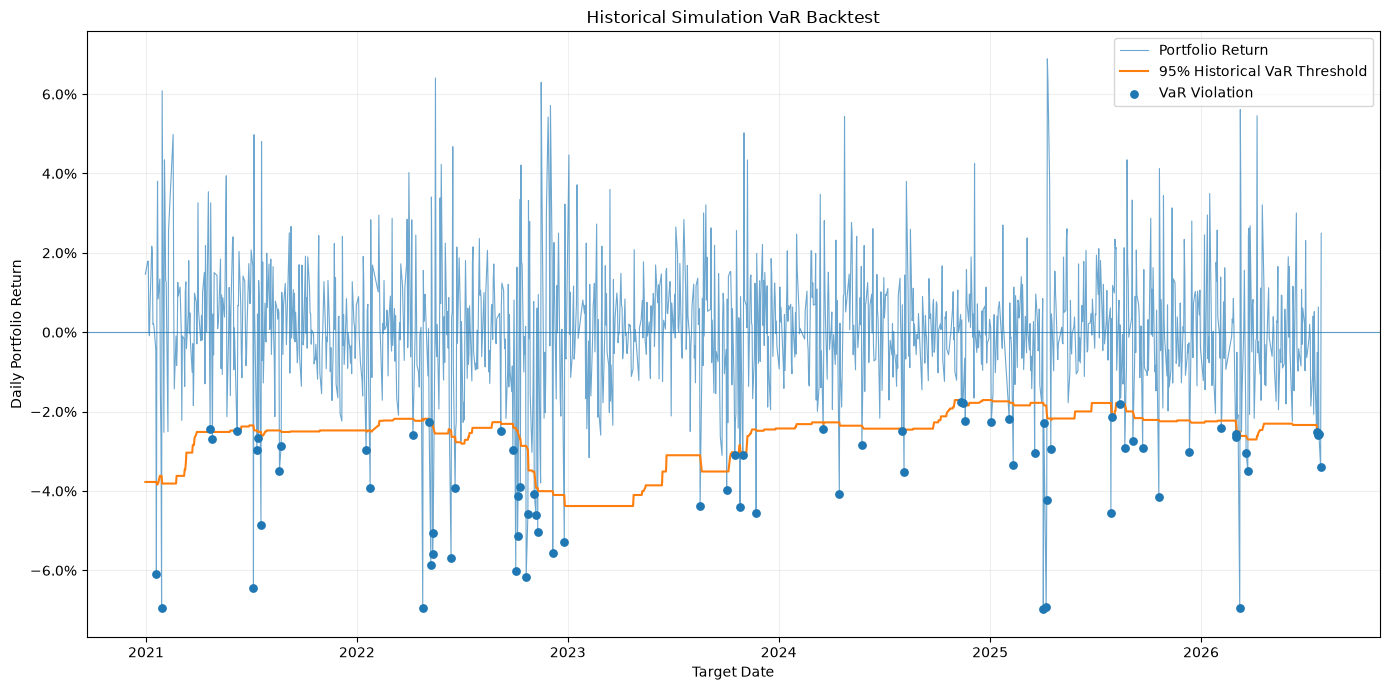

HISTORICAL VAR BACKTEST CHART
Rows plotted: 1387
First target date: 2020-12-31
Last target date: 2026-07-28
Figure path: C:\Users\Admin\Downloads\portfolio-var-risk-system\figures\var\09_historical_var_backtest.png
Figure size: 795483 bytes


In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plot_data = (
    historical_backtest[
        [
            "target_date",
            "target_return",
            "quantile_return",
            "violation",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(plot_data) == 1387

assert (
    plot_data
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    plot_data["target_date"]
    .is_monotonic_increasing
)

assert (
    plot_data["violation"]
    .equals(
        plot_data["target_return"]
        < plot_data["quantile_return"]
    )
)

violation_points = (
    plot_data.loc[
        plot_data["violation"]
    ]
    .copy()
)

assert (
    violation_points["target_return"]
    .lt(
        violation_points["quantile_return"]
    )
    .all()
)

figure_path = (
    PROJECT_ROOT
    / "figures"
    / "var"
    / "09_historical_var_backtest.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

fig, ax = plt.subplots(
    figsize=(14, 7)
)

ax.plot(
    plot_data["target_date"],
    plot_data["target_return"],
    linewidth=0.8,
    alpha=0.65,
    label="Portfolio Return",
)

ax.plot(
    plot_data["target_date"],
    plot_data["quantile_return"],
    linewidth=1.5,
    label="95% Historical VaR Threshold",
)

ax.scatter(
    violation_points["target_date"],
    violation_points["target_return"],
    s=28,
    zorder=3,
    label="VaR Violation",
)

ax.axhline(
    y=0.0,
    linewidth=0.8,
    alpha=0.7,
)

ax.set_title(
    "Historical Simulation VaR Backtest"
)

ax.set_xlabel(
    "Target Date"
)

ax.set_ylabel(
    "Daily Portfolio Return"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=1.0,
        decimals=1,
    )
)

ax.legend()

ax.grid(
    alpha=0.2
)

fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

assert figure_path.exists()

figure_size = (
    figure_path.stat().st_size
)

assert figure_size > 0

print(
    "HISTORICAL VAR BACKTEST CHART"
)

print(
    "Rows plotted:",
    len(plot_data),
)

print(
    "First target date:",
    plot_data[
        "target_date"
    ].iloc[0].date(),
)

print(
    "Last target date:",
    plot_data[
        "target_date"
    ].iloc[-1].date(),
)

print(
    "Figure path:",
    figure_path.resolve(),
)

print(
    "Figure size:",
    figure_size,
    "bytes",
)

In [16]:
assert figure_path.exists()

figure_size = (
    figure_path.stat().st_size
)

assert figure_size > 0

print(
    "Figure path:",
    figure_path.resolve(),
)

print(
    "Figure size:",
    figure_size,
    "bytes",
)

print(
    "\nBACKTEST CHART: PASS"
)

Figure path: C:\Users\Admin\Downloads\portfolio-var-risk-system\figures\var\09_historical_var_backtest.png
Figure size: 795483 bytes

BACKTEST CHART: PASS


In [17]:
BACKTEST_COLUMNS = [
    "window_start_date",
    "window_end_date",
    "forecast_date",
    "target_date",
    "observations",
    "quantile_return",
    "historical_var",
    "target_return",
    "violation",
]

VIOLATION_COLUMNS = [
    "target_date",
    "target_return",
    "quantile_return",
    "historical_var",
]

BACKTEST_DATE_COLUMNS = [
    "window_start_date",
    "window_end_date",
    "forecast_date",
    "target_date",
]

BACKTEST_NUMERIC_COLUMNS = [
    "quantile_return",
    "historical_var",
    "target_return",
]

VIOLATION_NUMERIC_COLUMNS = [
    "target_return",
    "quantile_return",
    "historical_var",
]

BACKTEST_OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "historical_var_backtest.csv"
)

VIOLATION_OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "historical_var_violations.csv"
)

VIOLATION_SAMPLE_PATH = (
    PROJECT_ROOT
    / "data"
    / "sample"
    / "historical_var_violation_sample.csv"
)

BACKTEST_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

VIOLATION_SAMPLE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

backtest_output = (
    historical_backtest[
        BACKTEST_COLUMNS
    ]
    .copy()
    .reset_index(drop=True)
)

violation_output = (
    violation_table[
        VIOLATION_COLUMNS
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(violation_output) >= 15

middle_start = (
    len(violation_output) // 2
    - 2
)

violation_sample = pd.concat(
    [
        violation_output.head(5),
        violation_output.iloc[
            middle_start:
            middle_start + 5
        ],
        violation_output.tail(5),
    ],
    ignore_index=True,
)

violation_sample = (
    violation_sample
    .drop_duplicates(
        subset="target_date"
    )
    .reset_index(drop=True)
)

assert len(violation_sample) == 15

backtest_output.to_csv(
    BACKTEST_OUTPUT_PATH,
    index=False,
)

violation_output.to_csv(
    VIOLATION_OUTPUT_PATH,
    index=False,
)

violation_sample.to_csv(
    VIOLATION_SAMPLE_PATH,
    index=False,
)

backtest_roundtrip = pd.read_csv(
    BACKTEST_OUTPUT_PATH
)

violation_roundtrip = pd.read_csv(
    VIOLATION_OUTPUT_PATH
)

sample_roundtrip = pd.read_csv(
    VIOLATION_SAMPLE_PATH
)

for date_col in BACKTEST_DATE_COLUMNS:
    backtest_roundtrip[
        date_col
    ] = pd.to_datetime(
        backtest_roundtrip[
            date_col
        ],
        errors="raise",
    )

violation_roundtrip[
    "target_date"
] = pd.to_datetime(
    violation_roundtrip[
        "target_date"
    ],
    errors="raise",
)

sample_roundtrip[
    "target_date"
] = pd.to_datetime(
    sample_roundtrip[
        "target_date"
    ],
    errors="raise",
)

assert len(backtest_roundtrip) == 1387

assert (
    backtest_roundtrip.columns.tolist()
    == BACKTEST_COLUMNS
)

assert (
    violation_roundtrip.columns.tolist()
    == VIOLATION_COLUMNS
)

assert (
    sample_roundtrip.columns.tolist()
    == VIOLATION_COLUMNS
)

assert (
    backtest_roundtrip
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    violation_roundtrip
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    sample_roundtrip
    .isna()
    .sum()
    .sum()
    == 0
)

assert not backtest_roundtrip[
    "target_date"
].duplicated().any()

assert not violation_roundtrip[
    "target_date"
].duplicated().any()

assert not sample_roundtrip[
    "target_date"
].duplicated().any()

assert (
    backtest_roundtrip[
        "violation"
    ]
    .equals(
        backtest_roundtrip[
            "target_return"
        ]
        < backtest_roundtrip[
            "quantile_return"
        ]
    )
)

assert (
    violation_roundtrip[
        "target_return"
    ]
    .lt(
        violation_roundtrip[
            "quantile_return"
        ]
    )
    .all()
)

assert (
    sample_roundtrip[
        "target_return"
    ]
    .lt(
        sample_roundtrip[
            "quantile_return"
        ]
    )
    .all()
)

backtest_numeric_difference = np.abs(
    backtest_roundtrip[
        BACKTEST_NUMERIC_COLUMNS
    ].to_numpy()
    - backtest_output[
        BACKTEST_NUMERIC_COLUMNS
    ].to_numpy()
)

violation_numeric_difference = np.abs(
    violation_roundtrip[
        VIOLATION_NUMERIC_COLUMNS
    ].to_numpy()
    - violation_output[
        VIOLATION_NUMERIC_COLUMNS
    ].to_numpy()
)

sample_numeric_difference = np.abs(
    sample_roundtrip[
        VIOLATION_NUMERIC_COLUMNS
    ].to_numpy()
    - violation_sample[
        VIOLATION_NUMERIC_COLUMNS
    ].to_numpy()
)

max_backtest_difference = float(
    backtest_numeric_difference.max()
)

max_violation_difference = float(
    violation_numeric_difference.max()
)

max_sample_difference = float(
    sample_numeric_difference.max()
)

assert max_backtest_difference <= 1e-12
assert max_violation_difference <= 1e-12
assert max_sample_difference <= 1e-12

print(
    "HISTORICAL VAR BACKTEST EXPORT"
)

print(
    "Backtest output:",
    BACKTEST_OUTPUT_PATH.resolve(),
)

print(
    "Backtest rows:",
    len(backtest_roundtrip),
)

print(
    "Violation output:",
    VIOLATION_OUTPUT_PATH.resolve(),
)

print(
    "Sample output:",
    VIOLATION_SAMPLE_PATH.resolve(),
)

print(
    "Sample rows:",
    len(sample_roundtrip),
)

print(
    "Maximum backtest round trip difference:",
    f"{max_backtest_difference:.3e}",
)

print(
    "Maximum violation round trip difference:",
    f"{max_violation_difference:.3e}",
)

print(
    "Maximum sample round trip difference:",
    f"{max_sample_difference:.3e}",
)

print(
    "\nViolation sample:"
)

print(
    sample_roundtrip.to_string(
        index=False
    )
)

HISTORICAL VAR BACKTEST EXPORT
Backtest output: C:\Users\Admin\Downloads\portfolio-var-risk-system\data\processed\historical_var_backtest.csv
Backtest rows: 1387
Violation output: C:\Users\Admin\Downloads\portfolio-var-risk-system\data\processed\historical_var_violations.csv
Sample output: C:\Users\Admin\Downloads\portfolio-var-risk-system\data\sample\historical_var_violation_sample.csv
Sample rows: 15
Maximum backtest round trip difference: 9.714e-17
Maximum violation round trip difference: 9.714e-17
Maximum sample round trip difference: 9.021e-17

Violation sample:
target_date  target_return  quantile_return  historical_var
 2021-01-19      -0.060883        -0.037728        0.037728
 2021-01-28      -0.069552        -0.036194        0.036194
 2021-04-22      -0.024475        -0.024062        0.024062
 2021-04-26      -0.026977        -0.024782        0.024782
 2021-06-08      -0.024962        -0.024782        0.024782
 2023-10-03      -0.039877        -0.035094        0.035094
 2023-

## Historical VaR Backtest Metrics

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd


current_path = Path.cwd().resolve()

if current_path.name == "notebooks":
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path


assert (
    PROJECT_ROOT
    / "data"
).exists()

assert (
    PROJECT_ROOT
    / "notebooks"
).exists()


print(
    "PROJECT_ROOT:",
    PROJECT_ROOT,
)

PROJECT_ROOT: C:\Users\Admin\Downloads\portfolio-var-risk-system


In [4]:
BACKTEST_INPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "historical_var_backtest.csv"
)

EXPECTED_BACKTEST_COLUMNS = [
    "window_start_date",
    "window_end_date",
    "forecast_date",
    "target_date",
    "observations",
    "quantile_return",
    "historical_var",
    "target_return",
    "violation",
]

DATE_COLUMNS = [
    "window_start_date",
    "window_end_date",
    "forecast_date",
    "target_date",
]

NUMERIC_COLUMNS = [
    "quantile_return",
    "historical_var",
    "target_return",
]

assert BACKTEST_INPUT_PATH.exists()

backtest_data = pd.read_csv(
    BACKTEST_INPUT_PATH,
    parse_dates=DATE_COLUMNS,
)

assert (
    backtest_data.columns.tolist()
    == EXPECTED_BACKTEST_COLUMNS
)

assert len(backtest_data) == 1387

assert (
    backtest_data
    .isna()
    .sum()
    .sum()
    == 0
)

assert not backtest_data[
    "target_date"
].duplicated().any()

assert (
    backtest_data[
        "target_date"
    ]
    .is_monotonic_increasing
)

assert (
    backtest_data[
        "observations"
    ]
    .eq(250)
    .all()
)

assert (
    backtest_data[
        "forecast_date"
    ]
    .equals(
        backtest_data[
            "window_end_date"
        ]
    )
)

assert (
    backtest_data[
        "forecast_date"
    ]
    .lt(
        backtest_data[
            "target_date"
        ]
    )
    .all()
)

assert pd.api.types.is_bool_dtype(
    backtest_data["violation"]
)

assert (
    backtest_data[
        "historical_var"
    ]
    .ge(0.0)
    .all()
)

assert (
    backtest_data[
        "quantile_return"
    ]
    .le(0.0)
    .all()
)

expected_var = np.maximum(
    0.0,
    -backtest_data[
        "quantile_return"
    ].to_numpy(),
)

var_convention_difference = np.abs(
    backtest_data[
        "historical_var"
    ].to_numpy()
    - expected_var
)

max_var_convention_difference = float(
    var_convention_difference.max()
)

expected_violation = (
    backtest_data[
        "target_return"
    ]
    < backtest_data[
        "quantile_return"
    ]
)

assert (
    backtest_data[
        "violation"
    ]
    .equals(
        expected_violation
    )
)

assert np.isfinite(
    backtest_data[
        NUMERIC_COLUMNS
    ].to_numpy()
).all()

assert max_var_convention_difference <= 1e-12

missing_values = int(
    backtest_data
    .isna()
    .sum()
    .sum()
)

duplicate_target_dates = int(
    backtest_data[
        "target_date"
    ]
    .duplicated()
    .sum()
)

print(
    "HISTORICAL VAR METRICS INPUT AUDIT"
)

print(
    "Input path:",
    BACKTEST_INPUT_PATH.resolve(),
)

print(
    "Rows:",
    len(backtest_data),
)

print(
    "First target date:",
    backtest_data[
        "target_date"
    ].iloc[0].date(),
)

print(
    "Last target date:",
    backtest_data[
        "target_date"
    ].iloc[-1].date(),
)

print(
    "Columns:",
    backtest_data.columns.tolist(),
)

print(
    "Violation dtype:",
    backtest_data[
        "violation"
    ].dtype,
)

print(
    "Missing values:",
    missing_values,
)

print(
    "Duplicate target dates:",
    duplicate_target_dates,
)

print(
    "Maximum VaR convention difference:",
    f"{max_var_convention_difference:.3e}",
)


HISTORICAL VAR METRICS INPUT AUDIT
Input path: C:\Users\Admin\Downloads\portfolio-var-risk-system\data\processed\historical_var_backtest.csv
Rows: 1387
First target date: 2020-12-31
Last target date: 2026-07-28
Columns: ['window_start_date', 'window_end_date', 'forecast_date', 'target_date', 'observations', 'quantile_return', 'historical_var', 'target_return', 'violation']
Violation dtype: bool
Missing values: 0
Duplicate target dates: 0
Maximum VaR convention difference: 0.000e+00


In [6]:
CONFIDENCE_LEVEL = 0.95

number_of_forecasts = len(
    backtest_data
)

number_of_violations = int(
    backtest_data[
        "violation"
    ].sum()
)

violation_rate = (
    number_of_violations
    / number_of_forecasts
)

expected_violation_rate = (
    1.0
    - CONFIDENCE_LEVEL
)

expected_violation_count = (
    number_of_forecasts
    * expected_violation_rate
)

violation_rate_difference = (
    violation_rate
    - expected_violation_rate
)

independent_violation = (
    backtest_data[
        "target_return"
    ]
    < backtest_data[
        "quantile_return"
    ]
)

independent_violation_count = int(
    independent_violation.sum()
)

independent_violation_rate = (
    independent_violation_count
    / number_of_forecasts
)

assert number_of_forecasts == 1387

assert (
    0
    <= number_of_violations
    <= number_of_forecasts
)

assert (
    0.0
    <= violation_rate
    <= 1.0
)

assert abs(
    expected_violation_rate
    - 0.05
) <= 1e-12

assert (
    independent_violation_count
    == number_of_violations
)

assert abs(
    independent_violation_rate
    - violation_rate
) <= 1e-12

print(
    "HISTORICAL VAR CORE BACKTEST METRICS"
)

print(
    "Number of forecasts:",
    number_of_forecasts,
)

print(
    "Number of violations:",
    number_of_violations,
)

print(
    "Violation rate:",
    f"{violation_rate:.6%}",
)

print(
    "Expected violation rate:",
    f"{expected_violation_rate:.6%}",
)

print(
    "Expected violation count:",
    f"{expected_violation_count:.2f}",
)

print(
    "Violation rate difference:",
    f"{violation_rate_difference:+.6%}",
)

print(
    "Independent violation count:",
    independent_violation_count,
)

HISTORICAL VAR CORE BACKTEST METRICS
Number of forecasts: 1387
Number of violations: 75
Violation rate: 5.407354%
Expected violation rate: 5.000000%
Expected violation count: 69.35
Violation rate difference: +0.407354%
Independent violation count: 75


In [26]:
PINBALL_ALPHA = 0.05

actual_returns = backtest_data["target_return"].to_numpy(dtype="float64")
quantile_forecasts = backtest_data["quantile_return"].to_numpy(dtype="float64")
pinball_error = actual_returns - quantile_forecasts

pinball_losses = np.maximum(PINBALL_ALPHA * pinball_error, (PINBALL_ALPHA - 1.0) * pinball_error)
pinball_losses_check = np.where(pinball_error >= 0.0, PINBALL_ALPHA * pinball_error, (PINBALL_ALPHA - 1.0) * pinball_error)

pinball_loss = float(pinball_losses.mean())
pinball_loss_check = float(pinball_losses_check.mean())
pinball_loss_difference = abs(pinball_loss - pinball_loss_check)

assert np.isfinite(pinball_losses).all()
assert np.all(pinball_losses >= 0.0)
assert pinball_loss_difference <= 1e-12

print(f"Pinball alpha: {PINBALL_ALPHA:.2f}")
print(f"Pinball Loss: {pinball_loss:.12f}")
print(f"Pinball Loss (% return scale): {pinball_loss:.6%}")
print(f"Independent check: {pinball_loss_check:.12f}")
print(f"Difference: {pinball_loss_difference:.3e}")

Pinball alpha: 0.05
Pinball Loss: 0.002057488935
Pinball Loss (% return scale): 0.205749%
Independent check: 0.002057488935
Difference: 0.000e+00


In [9]:
var_series = (
    backtest_data["historical_var"]
    .astype("float64")
)

assert not var_series.isna().any()

assert np.isfinite(
    var_series.to_numpy()
).all()

assert (
    var_series
    .ge(0.0)
    .all()
)

average_var = float(
    var_series.mean()
)

minimum_var = float(
    var_series.min()
)

maximum_var = float(
    var_series.max()
)

var_values = (
    var_series.to_numpy()
)

independent_average_var = float(
    np.mean(var_values)
)

independent_minimum_var = float(
    np.min(var_values)
)

independent_maximum_var = float(
    np.max(var_values)
)

average_difference = abs(
    average_var
    - independent_average_var
)

minimum_difference = abs(
    minimum_var
    - independent_minimum_var
)

maximum_difference = abs(
    maximum_var
    - independent_maximum_var
)

assert average_difference <= 1e-12
assert minimum_difference <= 1e-12
assert maximum_difference <= 1e-12

assert (
    minimum_var
    <= average_var
    <= maximum_var
)

print("HISTORICAL VAR DESCRIPTIVE METRICS")

print(f"Average VaR: {average_var:.6%}")
print(f"Minimum VaR: {minimum_var:.6%}")
print(f"Maximum VaR: {maximum_var:.6%}")

print(
    f"Average validation difference: "
    f"{average_difference:.3e}"
)

print(
    f"Minimum validation difference: "
    f"{minimum_difference:.3e}"
)

print(
    f"Maximum validation difference: "
    f"{maximum_difference:.3e}"
)

HISTORICAL VAR DESCRIPTIVE METRICS
Average VaR: 2.623147%
Minimum VaR: 1.708839%
Maximum VaR: 4.378557%
Average validation difference: 0.000e+00
Minimum validation difference: 0.000e+00
Maximum validation difference: 0.000e+00


In [11]:
ROLLING_WINDOW = 250

historical_var_summary = pd.DataFrame({
    "metric": [
        "Confidence Level", "Rolling Window", "Number of Forecasts", "Number of Violations",
        "Expected Violation Count", "Observed Violation Rate", "Expected Violation Rate",
        "Violation Rate Difference", "Pinball Loss", "Average VaR", "Minimum VaR", "Maximum VaR",
    ],
    "value": [
        CONFIDENCE_LEVEL, ROLLING_WINDOW, number_of_forecasts, number_of_violations,
        expected_violation_count, violation_rate, expected_violation_rate,
        violation_rate_difference, pinball_loss, average_var, minimum_var, maximum_var,
    ],
    "display_value": [
        f"{CONFIDENCE_LEVEL:.2%}", f"{ROLLING_WINDOW} sessions", f"{number_of_forecasts}",
        f"{number_of_violations}", f"{expected_violation_count:.2f}", f"{violation_rate:.6%}",
        f"{expected_violation_rate:.6%}", f"{violation_rate_difference:+.6%}",
        f"{pinball_loss:.6%}", f"{average_var:.6%}", f"{minimum_var:.6%}", f"{maximum_var:.6%}",
    ],
})

assert len(historical_var_summary) == 12
assert historical_var_summary.isna().sum().sum() == 0
assert not historical_var_summary["metric"].duplicated().any()

summary_values = historical_var_summary.set_index("metric")["value"]

assert int(summary_values["Number of Forecasts"]) == 1387
assert int(summary_values["Number of Violations"]) == 75
assert abs(summary_values["Observed Violation Rate"] - (75 / 1387)) <= 1e-12
assert abs(summary_values["Pinball Loss"] - 0.002057488935) <= 1e-12
assert summary_values["Minimum VaR"] <= summary_values["Average VaR"] <= summary_values["Maximum VaR"]

print("HISTORICAL VAR BACKTEST SUMMARY")
print(f"\n{historical_var_summary.to_string(index=False)}")
print(f"\nSummary rows: {len(historical_var_summary)}")
print(f"Pinball Loss: {summary_values['Pinball Loss']:.12f}")

HISTORICAL VAR BACKTEST SUMMARY

                   metric       value display_value
         Confidence Level    0.950000        95.00%
           Rolling Window  250.000000  250 sessions
      Number of Forecasts 1387.000000          1387
     Number of Violations   75.000000            75
 Expected Violation Count   69.350000         69.35
  Observed Violation Rate    0.054074     5.407354%
  Expected Violation Rate    0.050000     5.000000%
Violation Rate Difference    0.004074    +0.407354%
             Pinball Loss    0.002057     0.205749%
              Average VaR    0.026231     2.623147%
              Minimum VaR    0.017088     1.708839%
              Maximum VaR    0.043786     4.378557%

Summary rows: 12
Pinball Loss: 0.002057488935


In [ ]:
CALIBRATION_TOLERANCE = 1e-12

excess_violation_count = (
    number_of_violations
    - expected_violation_count
)

if abs(
    violation_rate
    - expected_violation_rate
) <= CALIBRATION_TOLERANCE:
    calibration_direction = (
        "At expected level"
    )
elif (
    violation_rate
    > expected_violation_rate
):
    calibration_direction = (
        "Above expected"
    )
else:
    calibration_direction = (
        "Below expected"
    )

assert (
    violation_rate
    > expected_violation_rate
)

assert (
    calibration_direction
    == "Above expected"
)

assert (
    excess_violation_count
    > 0.0
)

calibration_interpretation = (
    "The observed violation rate is slightly above "
    "the nominal 5% level. This provides descriptive "
    "evidence of mild undercoverage, meaning Historical "
    "Simulation shows a small tendency to underestimate "
    "one-day tail risk over the backtest period. "
    "This is not a formal statistical rejection of the "
    "model because no coverage hypothesis test is applied "
    "at this stage."
)

print("HISTORICAL VAR CALIBRATION INTERPRETATION")

print(
    f"Observed violation rate: "
    f"{violation_rate:.6%}"
)

print(
    f"Expected violation rate: "
    f"{expected_violation_rate:.6%}"
)

print(
    f"Violation rate difference: "
    f"{violation_rate_difference:+.6%}"
)

print(
    f"Observed violations: "
    f"{number_of_violations}"
)

print(
    f"Expected violations: "
    f"{expected_violation_count:.2f}"
)

print(
    f"Excess violations: "
    f"{excess_violation_count:+.2f}"
)

print(
    f"Calibration direction: "
    f"{calibration_direction}"
)

print(
    f"\nInterpretation: "
    f"{calibration_interpretation}"
)

HISTORICAL VAR CALIBRATION INTERPRETATION
Observed violation rate: 5.407354%
Expected violation rate: 5.000000%
Violation rate difference: +0.407354%
Observed violations: 75
Expected violations: 69.35
Excess violations: +5.65
Calibration direction: Above expected

Interpretation: The observed violation rate is slightly above the nominal 5% level. This provides descriptive evidence of mild undercoverage, meaning Historical Simulation shows a small tendency to underestimate one-day tail risk over the backtest period. This is not a formal statistical rejection of the model because no coverage hypothesis test is applied at this stage.

CALIBRATION INTERPRETATION: PASS


In [17]:
METRICS_OUTPUT_PATH = PROJECT_ROOT / "outputs" / "tables" / "historical_var_backtest_metrics.csv"
METRICS_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

metrics_output = historical_var_summary.copy().reset_index(drop=True)
metrics_output.to_csv(METRICS_OUTPUT_PATH, index=False)

metrics_roundtrip = pd.read_csv(METRICS_OUTPUT_PATH)
EXPECTED_METRICS_COLUMNS = ["metric", "value", "display_value"]

assert len(metrics_roundtrip) == 12
assert metrics_roundtrip.columns.tolist() == EXPECTED_METRICS_COLUMNS
assert metrics_roundtrip.isna().sum().sum() == 0
assert not metrics_roundtrip["metric"].duplicated().any()

roundtrip_values = metrics_roundtrip.set_index("metric")["value"]

assert int(roundtrip_values["Number of Forecasts"]) == 1387
assert int(roundtrip_values["Number of Violations"]) == 75
assert abs(roundtrip_values["Observed Violation Rate"] - violation_rate) <= 1e-12
assert abs(roundtrip_values["Pinball Loss"] - pinball_loss) <= 1e-12
assert abs(roundtrip_values["Average VaR"] - average_var) <= 1e-12

value_difference = np.abs(metrics_roundtrip["value"].to_numpy(dtype="float64") - metrics_output["value"].to_numpy(dtype="float64"))
max_roundtrip_difference = float(value_difference.max())

assert max_roundtrip_difference <= 1e-12
assert calibration_direction == "Above expected"
assert isinstance(calibration_interpretation, str) and calibration_interpretation.strip()

print("HISTORICAL VAR BACKTEST METRICS EXPORT")
print(f"Output path: {METRICS_OUTPUT_PATH.resolve()}")
print(f"Rows: {len(metrics_roundtrip)}")
print(f"Exported Pinball Loss: {roundtrip_values['Pinball Loss']:.12f}")
print(f"Maximum round-trip difference: {max_roundtrip_difference:.3e}")
print(f"Calibration direction: {calibration_direction}")

HISTORICAL VAR BACKTEST METRICS EXPORT
Output path: C:\Users\Admin\Downloads\portfolio-var-risk-system\outputs\tables\historical_var_backtest_metrics.csv
Rows: 12
Exported Pinball Loss: 0.002057488935
Maximum round-trip difference: 8.934e-17
Calibration direction: Above expected
